170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1830s 11us/step


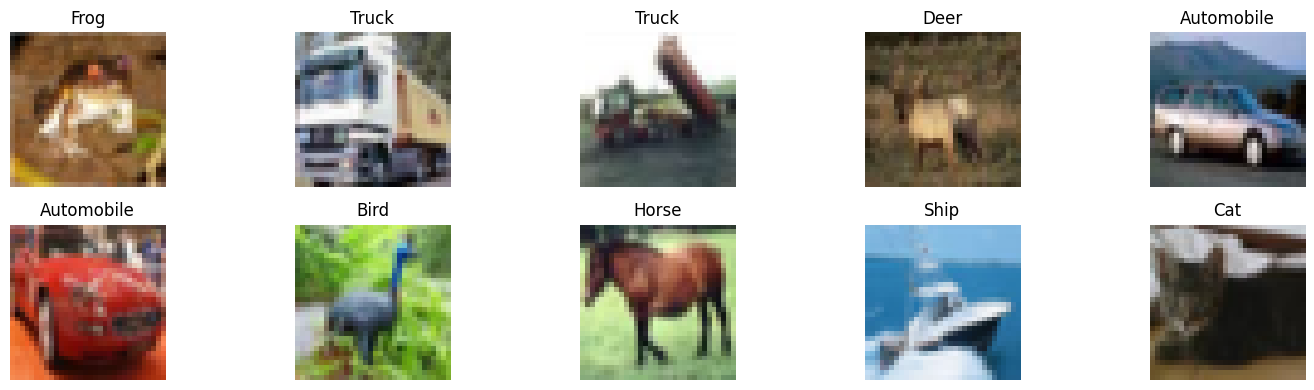

Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)

Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


In [ ]:
# ================================
# Task 1: Dataset Preparation
# ================================

import tensorflow as tf
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to the range [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Class names in CIFAR-10
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

# Display 10 sample images
plt.figure(figsize=(15,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Print dataset dimensions
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("\nTesting Images Shape :", x_test.shape)
print("Testing Labels Shape :", y_test.shape)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

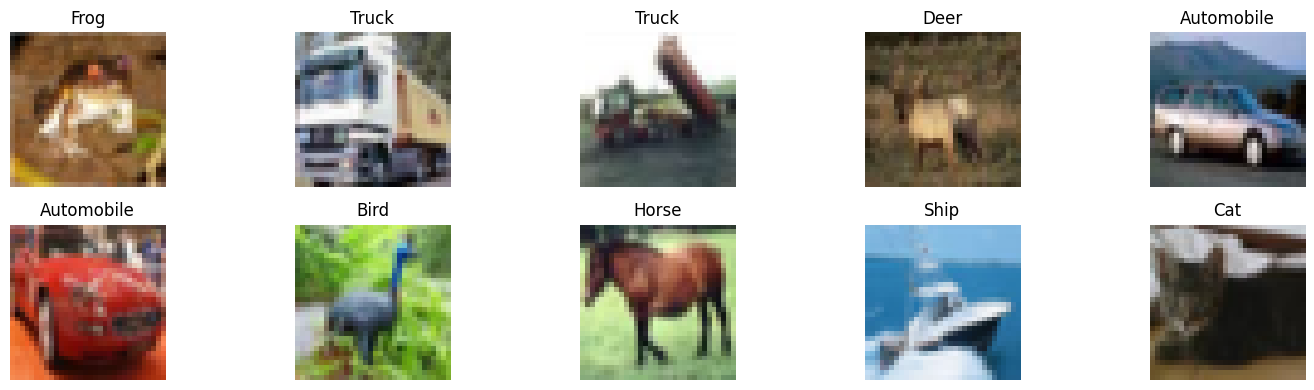

In [ ]:
# Display 10 sample images
plt.figure(figsize=(15,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()

# Save the figure as a PDF
plt.savefig("Task1_CIFAR10_Sample_Images.png",
            dpi=300,
            bbox_inches="tight")
from google.colab import files
files.download("Task1_CIFAR10_Sample_Images.png")

# Show the figure
plt.show()

In [ ]:
# ==========================================
# Task 2: Transfer Learning using MobileNetV2
# ==========================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# Load the pretrained MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',      # Load ImageNet pretrained weights
    include_top=False,       # Remove original classification layer
    input_shape=(32, 32, 3)
)

# Freeze the convolutional base
base_model.trainable = False

# Add custom classification layers
x = base_model.output

# Global Average Pooling Layer
x = GlobalAveragePooling2D()(x)

# Dense Layer with ReLU activation
x = Dense(128, activation='relu')(x)

# Output Layer with Softmax activation
outputs = Dense(10, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=outputs)

# Display the model summary
model.summary()

/tmp/ipykernel_549/4086014734.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Convert labels to one-hot encoding
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 46ms/step - accuracy: 0.3004 - loss: 1.9321 - val_accuracy: 0.3263 - val_loss: 1.8667
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.3363 - loss: 1.8304 - val_accuracy: 0.3397 - val_loss: 1.8286
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.3488 - loss: 1.7910 - val_accuracy: 0.3472 - val_loss: 1.8113
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.3605 - loss: 1.7636 - val_accuracy: 0.3536 - val_loss: 1.8020
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.3675 - loss: 1.7403 - val_accuracy: 0.3477 - val_loss: 1.7971
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.3747 - loss: 1.7215 - val_accuracy: 0.3573 - val_loss: 1.7947
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.3802 - loss: 1.7057 - val_accuracy: 0.3587 - val_loss: 1.7908
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.3868 -

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test_cat)

print(f"\nTest Loss : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.3554 - loss: 1.7987

Test Loss : 1.7987
Test Accuracy : 0.3554


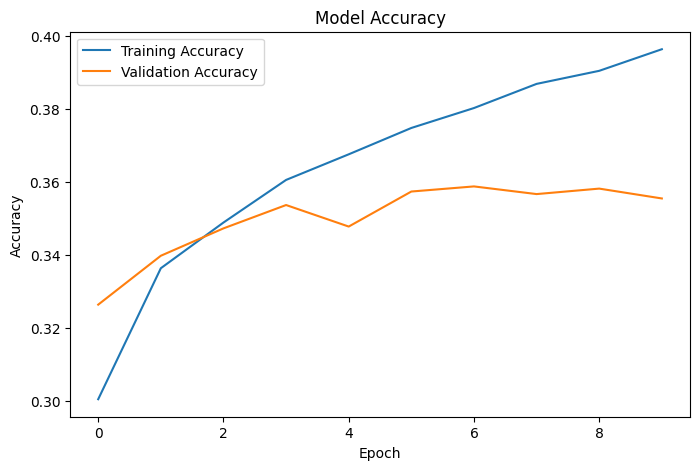

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("Task3_Training_Accuracy.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

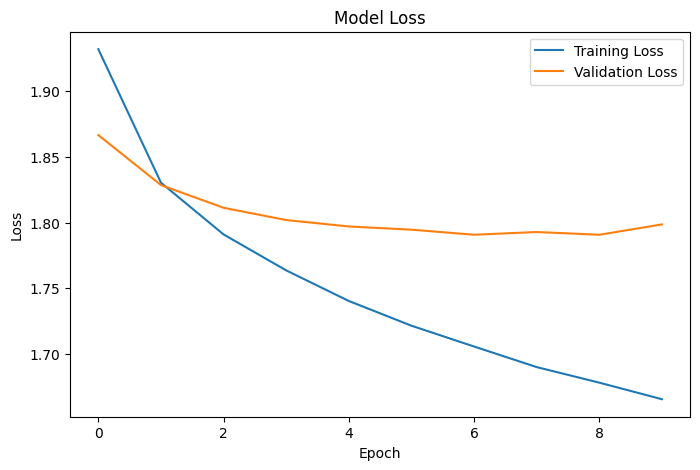

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("Task3_Training_Loss.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
#Task4
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fine_history = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=5,
    batch_size=32
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 153s 92ms/step - accuracy: 0.3197 - loss: 6.1044 - val_accuracy: 0.2000 - val_loss: 5.3056
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.4036 - loss: 2.0243 - val_accuracy: 0.3694 - val_loss: 2.0656
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.4685 - loss: 1.5819 - val_accuracy: 0.4893 - val_loss: 1.4926
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.5148 - loss: 1.3800 - val_accuracy: 0.5405 - val_loss: 1.3273
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 90ms/step - accuracy: 0.5524 - loss: 1.2841 - val_accuracy: 0.5697 - val_loss: 1.2627


In [ ]:
fine_loss, fine_accuracy = model.evaluate(x_test, y_test_cat)

print(f"\nAccuracy Before Fine Tuning : {accuracy:.4f}")
print(f"Accuracy After Fine Tuning  : {fine_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.5697 - loss: 1.2627

Accuracy Before Fine Tuning : 0.3554
Accuracy After Fine Tuning  : 0.5697


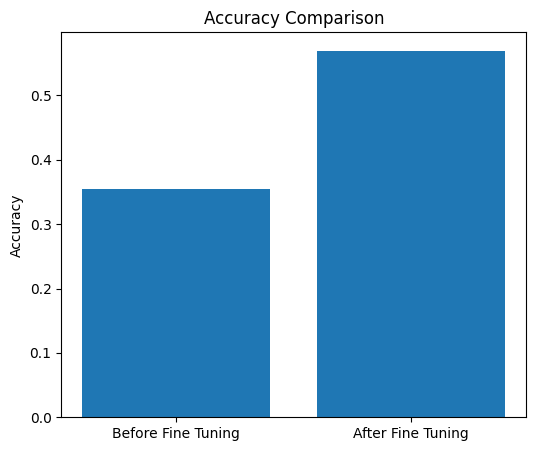

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Before Fine Tuning', 'After Fine Tuning'],
    [accuracy, fine_accuracy]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

plt.savefig("Task4_Fine_Tuning_Comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
#Task 5
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt

In [ ]:
# Predict probabilities
y_pred_prob = model.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot labels to class labels
y_true = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.5697
Precision: 0.5686589099758084
Recall   : 0.5697
F1 Score : 0.5665553918021374


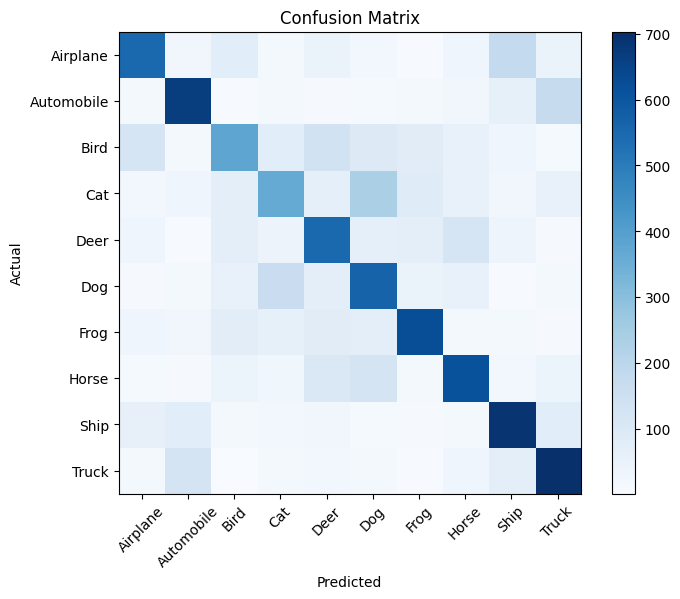

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

classes = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("Task5_Confusion_Matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

    Airplane       0.64      0.55      0.59      1000
  Automobile       0.67      0.67      0.67      1000
        Bird       0.48      0.38      0.42      1000
         Cat       0.46      0.36      0.41      1000
        Deer       0.50      0.55      0.52      1000
         Dog       0.46      0.56      0.51      1000
        Frog       0.65      0.62      0.63      1000
       Horse       0.60      0.61      0.61      1000
        Ship       0.61      0.69      0.65      1000
       Truck       0.62      0.70      0.66      1000

    accuracy                           0.57     10000
   macro avg       0.57      0.57      0.57     10000
weighted avg       0.57      0.57      0.57     10000



In [ ]:
# Experiment 2 - Learning Rate = 0.0001

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_lr = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=10,
    batch_size=32
)

loss_lr, acc_lr = model.evaluate(x_test, y_test_cat)

print("Learning Rate = 0.0001")
print("Accuracy =", acc_lr)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 153s 92ms/step - accuracy: 0.5755 - loss: 1.2151 - val_accuracy: 0.5709 - val_loss: 1.3112
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.5953 - loss: 1.1503 - val_accuracy: 0.5924 - val_loss: 1.2002
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.6157 - loss: 1.0889 - val_accuracy: 0.6106 - val_loss: 1.1648
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 92ms/step - accuracy: 0.6329 - loss: 1.0438 - val_accuracy: 0.6089 - val_loss: 1.1562
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 92ms/step - accuracy: 0.6459 - loss: 1.0020 - val_accuracy: 0.6176 - val_loss: 1.1595
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 211s 98ms/step - accuracy: 0.6604 - loss: 0.9598 - val_accuracy: 0.6177 - val_loss: 1.1587
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 92ms/step - accuracy: 0.6735 - loss: 0.9250 - val_accuracy: 0.6098 - val_loss: 1.1936
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 

In [ ]:
# Experiment 3 - Batch Size = 16

history_bs16 = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=10,
    batch_size=16
)

loss_bs16, acc_bs16 = model.evaluate(x_test, y_test_cat)

print("Batch Size = 16")
print("Accuracy =", acc_bs16)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 182s 58ms/step - accuracy: 0.6336 - loss: 1.0458 - val_accuracy: 0.6043 - val_loss: 1.1730
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 181s 58ms/step - accuracy: 0.6397 - loss: 1.0266 - val_accuracy: 0.6042 - val_loss: 1.2094
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 181s 58ms/step - accuracy: 0.6459 - loss: 1.0037 - val_accuracy: 0.6217 - val_loss: 1.1578
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 181s 58ms/step - accuracy: 0.6547 - loss: 0.9803 - val_accuracy: 0.6233 - val_loss: 1.1441
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 179s 57ms/step - accuracy: 0.6580 - loss: 0.9656 - val_accuracy: 0.6247 - val_loss: 1.1664
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 180s 58ms/step - accuracy: 0.6655 - loss: 0.9496 - val_accuracy: 0.6243 - val_loss: 1.1716
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 181s 58ms/step - accuracy: 0.6678 - loss: 0.9414 - val_accuracy: 0.6193 - val_loss: 1.1685
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 180s 58ms/step - accuracy: 

In [ ]:
# ============================================
# Hyperparameter Study - Batch Size = 64
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_bs64 = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=10,
    batch_size=64
)

loss_bs64, acc_bs64 = model.evaluate(x_test, y_test_cat)

print("Batch Size = 64")
print("Accuracy =", acc_bs64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 129s 153ms/step - accuracy: 0.6312 - loss: 1.0713 - val_accuracy: 0.5146 - val_loss: 1.9547
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 150ms/step - accuracy: 0.6534 - loss: 1.0109 - val_accuracy: 0.4932 - val_loss: 2.1823
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 118s 150ms/step - accuracy: 0.6714 - loss: 0.9464 - val_accuracy: 0.5366 - val_loss: 2.0432
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 118s 151ms/step - accuracy: 0.6860 - loss: 0.8934 - val_accuracy: 0.5030 - val_loss: 1.9427
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 150ms/step - accuracy: 0.7024 - loss: 0.8497 - val_accuracy: 0.5026 - val_loss: 2.0180
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 120s 154ms/step - accuracy: 0.7141 - loss: 0.8082 - val_accuracy: 0.5528 - val_loss: 1.6439
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 118s 150ms/step - accuracy: 0.7286 - loss: 0.7721 - val_accuracy: 0.5672 - val_loss: 1.5308
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 151ms/step - accuracy: 0.7416 -

In [ ]:
# ============================================
# Hyperparameter Study - Epochs = 20
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ep20 = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=20,
    batch_size=32
)

loss_ep20, acc_ep20 = model.evaluate(x_test, y_test_cat)

print("Epochs = 20")
print("Accuracy =", acc_ep20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 154s 93ms/step - accuracy: 0.7044 - loss: 0.8476 - val_accuracy: 0.5855 - val_loss: 1.5559
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 92ms/step - accuracy: 0.7078 - loss: 0.8301 - val_accuracy: 0.5931 - val_loss: 1.4130
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.7204 - loss: 0.7971 - val_accuracy: 0.5614 - val_loss: 1.5580
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.7245 - loss: 0.7833 - val_accuracy: 0.5942 - val_loss: 1.3993
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 92ms/step - accuracy: 0.7390 - loss: 0.7438 - val_accuracy: 0.5877 - val_loss: 1.4363
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 92ms/step - accuracy: 0.7429 - loss: 0.7311 - val_accuracy: 0.5902 - val_loss: 1.5446
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 91ms/step - accuracy: 0.7504 - loss: 0.7064 - val_accuracy: 0.6121 - val_loss: 1.3914
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 92ms/step - accuracy: 

In [ ]:
# ============================================
# Hyperparameter Study - Optimizer = SGD
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=10,
    batch_size=32
)

loss_sgd, acc_sgd = model.evaluate(x_test, y_test_cat)

print("Optimizer = SGD")
print("Accuracy =", acc_sgd)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 84ms/step - accuracy: 0.8551 - loss: 0.4102 - val_accuracy: 0.6430 - val_loss: 1.4288
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.8573 - loss: 0.4020 - val_accuracy: 0.6470 - val_loss: 1.4203
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.8611 - loss: 0.3903 - val_accuracy: 0.6483 - val_loss: 1.4327
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.8628 - loss: 0.3858 - val_accuracy: 0.6479 - val_loss: 1.4344
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.8655 - loss: 0.3791 - val_accuracy: 0.6481 - val_loss: 1.4407
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.8678 - loss: 0.3715 - val_accuracy: 0.6498 - val_loss: 1.4502
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.8705 - loss: 0.3690 - val_accuracy: 0.6500 - val_loss: 1.4568
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 

In [ ]:
# ============================================
# Hyperparameter Study - Dense Units = 256
# ============================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

# Changed from 128 to 256
x = Dense(256, activation='relu')(x)

outputs = Dense(10, activation='softmax')(x)

model_dense256 = Model(inputs=base_model.input, outputs=outputs)

/tmp/ipykernel_549/3532883660.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [ ]:
model_dense256.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_dense256 = model_dense256.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=10,
    batch_size=32
)

loss_dense256, acc_dense256 = model_dense256.evaluate(x_test, y_test_cat)

print("Dense Units = 256")
print("Accuracy =", acc_dense256)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 53ms/step - accuracy: 0.3072 - loss: 1.9101 - val_accuracy: 0.3315 - val_loss: 1.8441
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.3429 - loss: 1.8065 - val_accuracy: 0.3418 - val_loss: 1.8143
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.3598 - loss: 1.7630 - val_accuracy: 0.3486 - val_loss: 1.7936
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.3736 - loss: 1.7310 - val_accuracy: 0.3530 - val_loss: 1.7941
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.3802 - loss: 1.7054 - val_accuracy: 0.3578 - val_loss: 1.7868
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.3888 - loss: 1.6814 - val_accuracy: 0.3571 - val_loss: 1.7881
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.3977 - loss: 1.6618 - val_accuracy: 0.3557 - val_loss: 1.7823
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.4041 -

In [ ]:
# Load pretrained MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

/tmp/ipykernel_549/1866322986.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [ ]:
model_partial = Model(inputs=base_model.input, outputs=outputs)

In [ ]:
model_partial.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_partial = model_partial.fit(
    x_train,
    y_train_cat,
    validation_data=(x_test, y_test_cat),
    epochs=10,
    batch_size=32
)

loss_partial, acc_partial = model_partial.evaluate(x_test, y_test_cat)

print("Partial Frozen Layers Accuracy:", acc_partial)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 151s 91ms/step - accuracy: 0.5086 - loss: 1.4209 - val_accuracy: 0.3920 - val_loss: 1.9261
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.5729 - loss: 1.2281 - val_accuracy: 0.5027 - val_loss: 1.7005
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 153s 97ms/step - accuracy: 0.6003 - loss: 1.1566 - val_accuracy: 0.5240 - val_loss: 1.5002
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.6165 - loss: 1.1058 - val_accuracy: 0.5080 - val_loss: 1.6574
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.6272 - loss: 1.0660 - val_accuracy: 0.5693 - val_loss: 1.4784
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.6419 - loss: 1.0235 - val_accuracy: 0.6019 - val_loss: 1.2413
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 91ms/step - accuracy: 0.6570 - loss: 0.9784 - val_accuracy: 0.6045 - val_loss: 1.3050
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 

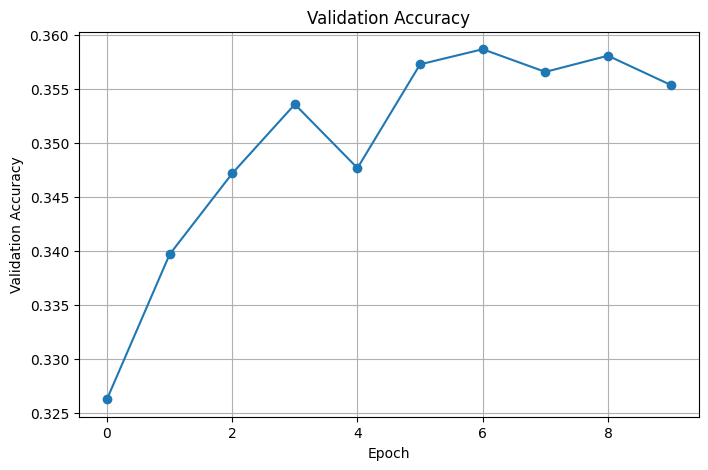

In [ ]:
#PLOTS
plt.figure(figsize=(8,5))

plt.plot(history.history['val_accuracy'], marker='o')

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True)

plt.savefig("Task3_Validation_Accuracy.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

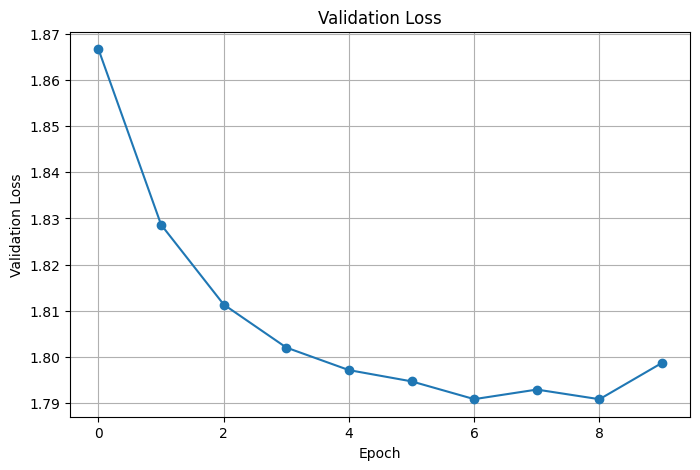

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['val_loss'], marker='o')

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True)

plt.savefig("Task3_Validation_Loss.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

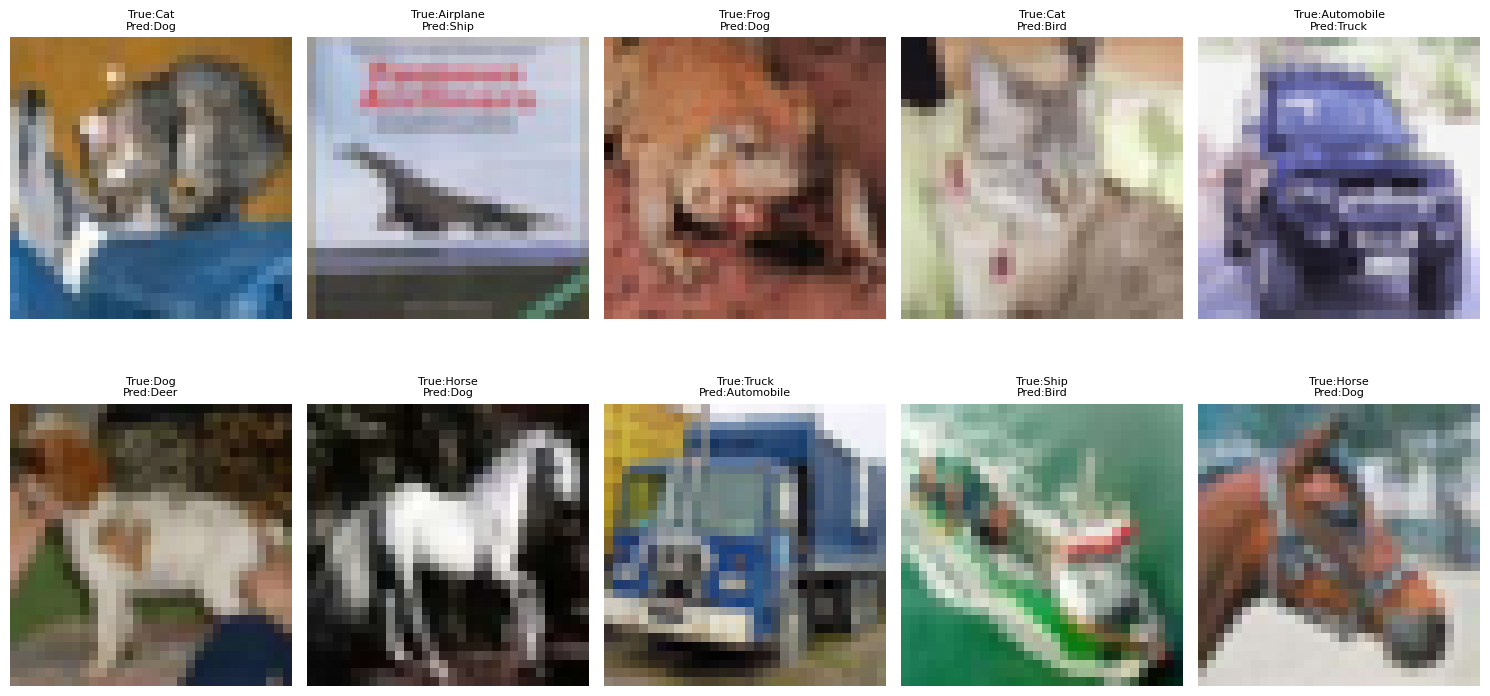

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

misclassified = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15,8))

for i in range(min(10, len(misclassified))):
    idx = misclassified[i]

    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx])

    plt.title(f"True:{classes[y_true[idx]]}\nPred:{classes[y_pred[idx]]}",
              fontsize=8)

    plt.axis('off')

plt.tight_layout()

plt.savefig("Task5_Misclassified_Images.png",
            dpi=300,
            bbox_inches='tight')

plt.show()